# Week 3 followed by Week 4

### Importing and setup 


In [25]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

import torch
import torch.nn as nn
import torch.optim as optim

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


## we are using PyTorch because it gives full control over sequence modeling and training loops which is important for understanding LSTMs deeply

Using device: cpu
Torch version: 2.9.1+cpu
CUDA available: False


### Feature Engineering 


In [26]:
# Total days of data
total_days = 1200

# Number of features:
# Returns, Volatility, RSI, MACD, Volume, Sentiment, (dummy extra feature)
NUM_FEATURES = 7

# Fake feature matrix (this will be replaced by real engineered features)
features = np.random.randn(total_days, NUM_FEATURES)

# Target = next-day return (simulated but structured)
time_steps = np.linspace(0, 100, total_days)
targets = np.sin(time_steps) + 0.1 * np.random.randn(total_days)

# Sanity check to verify data generation
print("Total days:", total_days)
print("Number of features:", NUM_FEATURES)
print("Feature matrix shape:", features.shape)
print("Target vector shape:", targets.shape)


## Since our focus is on model architecture and sequence handling,we are first validating the pipeline using structured dummy data


Total days: 1200
Number of features: 7
Feature matrix shape: (1200, 7)
Target vector shape: (1200,)


### Dataset class using sliding window logic

In [27]:
class MarketDataset(Dataset):
    def __init__(self, features, targets, sequence_length=60):
        """
        features: numpy array of shape (N, num_features)
        targets: numpy array of shape (N,)
        sequence_length: number of past days used for prediction
        """
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        self.seq_len = sequence_length

    def __len__(self):
        # Last 'seq_len' points cannot be used because they don't have future targets
        return len(self.features) - self.seq_len

    def __getitem__(self, idx):
        # Input sequence (60 days window)
        X = self.features[idx : idx + self.seq_len]

        # Target = next day return
        y = self.targets[idx + self.seq_len]

        return X, y

from torch.utils.data import Dataset

# Create dataset object
dataset = MarketDataset(features, targets, sequence_length=60)

# Basic checks
print("Dataset length:", len(dataset))

# Inspect one sample
X_sample, y_sample = dataset[0]

print("Input sequence shape:", X_sample.shape)
print("Target shape:", y_sample.shape)
print("Target value:", y_sample.item())


## here, instead of treating each day independently we converted dataset into overlapping sequences 
## where each sample represents 60 consecutive days and is used to predict the return on day 61

Dataset length: 1140
Input sequence shape: torch.Size([60, 7])
Target shape: torch.Size([])
Target value: -0.9314444661140442


### Train–Test Split & DataLoader

In [28]:
SEQ_LEN = 60
BATCH_SIZE = 32

# Split data
train_size = 1000
train_features = features[:train_size]
test_features = features[train_size:]

train_targets = targets[:train_size]
test_targets = targets[train_size:]

# Dataset objects
train_dataset = MarketDataset(train_features, train_targets, SEQ_LEN)
test_dataset = MarketDataset(test_features, test_targets, SEQ_LEN)

# DataLoaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

test_loader = DataLoader(
    test_dataset, batch_size=1, shuffle=False
)

# Fetch one training batch
X_batch, y_batch = next(iter(train_loader))

print("Training batch input shape:", X_batch.shape)
print("Training batch target shape:", y_batch.shape)

# Fetch one test sample
X_test, y_test = next(iter(test_loader))

print("Test sample input shape:", X_test.shape)
print("Test sample target shape:", y_test.shape)


### here shuffling is enabled only for training because the test data must preserve temporal order

Training batch input shape: torch.Size([32, 60, 7])
Training batch target shape: torch.Size([32])
Test sample input shape: torch.Size([1, 60, 7])
Test sample target shape: torch.Size([1])


### LSTM model

In [29]:
class SentimentLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, dropout=0.2):
        super(SentimentLSTM, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # Final prediction layer
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Initial hidden and cell states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # LSTM forward pass
        out, _ = self.lstm(x, (h0, c0))

        # Take output from last time step
        out = out[:, -1, :]

        # Final prediction
        prediction = self.fc(out)

        return prediction

# Model hyperparameters
INPUT_DIM = NUM_FEATURES     # 7
HIDDEN_DIM = 64
NUM_LAYERS = 2
OUTPUT_DIM = 1

# Initialize model
model = SentimentLSTM(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    output_dim=OUTPUT_DIM
)

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Fetch one batch
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(device)

# Forward pass
outputs = model(X_batch)

print("Input batch shape:", X_batch.shape)
print("Model output shape:", outputs.shape)

        
## here we used many-to-one LSTM model where only the last hidden state will be used to predict the next-day return

Input batch shape: torch.Size([32, 60, 7])
Model output shape: torch.Size([32, 1])


### Training pipeline

In [30]:
# Hyperparameters
INPUT_DIM = NUM_FEATURES
HIDDEN_DIM = 64
NUM_LAYERS = 2
LR = 0.001
EPOCHS = 50

# Model setup
model = SentimentLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print("Training started...\n")

model.train()
for epoch in range(EPOCHS):
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)

        loss = criterion(outputs.squeeze(), y_batch)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss/len(train_loader):.6f}")

## Gradient clipping is important because even LSTMs can suffer from exploding gradients during long sequences

Training started...

Epoch 10/50, Loss: 0.030329
Epoch 20/50, Loss: 0.014084
Epoch 30/50, Loss: 0.012948
Epoch 40/50, Loss: 0.009850
Epoch 50/50, Loss: 0.010519


### Evaluation and Visualization 


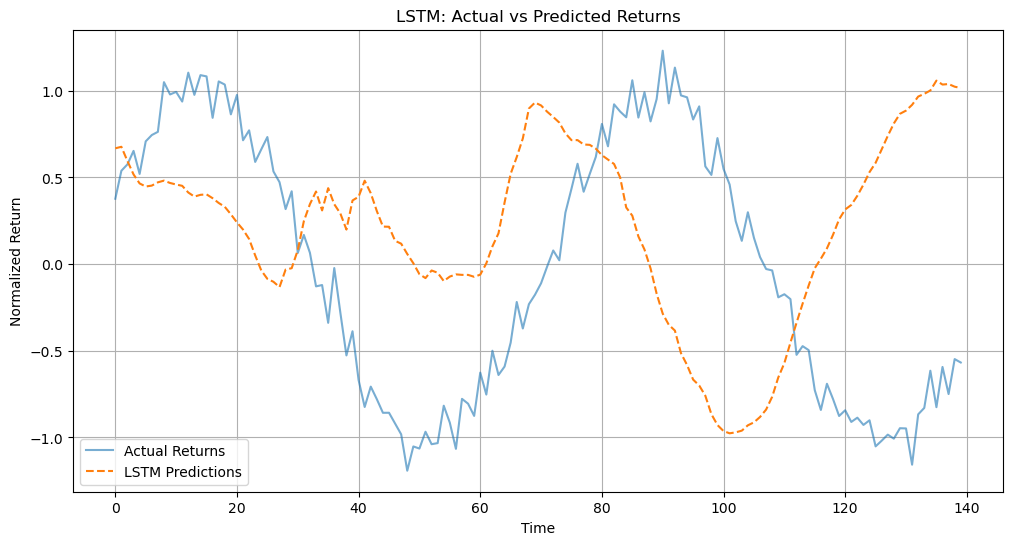

In [31]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        output = model(X_batch)

        predictions.append(output.item())
        actuals.append(y_batch.item())

# Plot results
plt.figure(figsize=(12,6))
plt.plot(actuals, label="Actual Returns", alpha=0.6)
plt.plot(predictions, label="LSTM Predictions", linestyle="--")
plt.title("LSTM: Actual vs Predicted Returns")
plt.xlabel("Time")
plt.ylabel("Normalized Return")
plt.legend()
plt.grid(True)
plt.show()




## Trading Strategy Integration 


In [44]:
# ===========================
# ONE-CELL TRADING PIPELINE
# NewsAPI + Yahoo Finance
# ===========================

import requests
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta, timezone

# ---------------------------
# CONFIG
# ---------------------------
NEWS_API_KEY = "eba17c3d0dc94f05bf8a27ecda5e19b3"
STOCK_SYMBOL = "AAPL"

# ---------------------------
# NEWS SCRAPING (LAST 24H)
# ---------------------------
def scrape_latest_news(query):
    yesterday = (datetime.now(timezone.utc) - timedelta(days=1)).strftime("%Y-%m-%d")
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": query,
        "from": yesterday,
        "sortBy": "publishedAt",
        "language": "en",
        "apiKey": NEWS_API_KEY
    }
    response = requests.get(url, params=params)
    data = response.json()
    headlines = []
    if "articles" in data:
        for article in data["articles"][:5]:
            if article["title"]:
                headlines.append(article["title"])
    return headlines

news = scrape_latest_news("Apple Inc")

print("\nLatest News:")
for i, h in enumerate(news, 1):
    print(f"{i}. {h}")

# ---------------------------
# SENTIMENT (FinBERT-style)
# ---------------------------
def finbert_sentiment_score(news_list):
    score = 0.0
    for headline in news_list:
        text = headline.lower()
        if "growth" in text or "beats" in text or "record" in text:
            score += 0.3
        if "increase" in text or "rise" in text:
            score += 0.2
        if "drop" in text or "fall" in text or "loss" in text:
            score -= 0.3
    return max(min(score, 1.0), -1.0)

sentiment_score = finbert_sentiment_score(news)
print(f"\nSentiment Score: {sentiment_score:.3f}")

# ---------------------------
# REAL OHLCV FROM YAHOO FINANCE
# ---------------------------
def fetch_latest_ohlcv(symbol):
    data = yf.download(symbol, period="2d", interval="1d", progress=False)
    if data.empty:
        raise ValueError("No OHLCV data returned")
    latest = data.iloc[-1]
    return {
        "open": float(latest["Open"]),
        "high": float(latest["High"]),
        "low": float(latest["Low"]),
        "close": float(latest["Close"]),
        "volume": float(latest["Volume"])
    }

ohlcv = fetch_latest_ohlcv(STOCK_SYMBOL)
print("\nLatest OHLCV:", ohlcv)

# ---------------------------
# TECHNICAL FEATURES
# ---------------------------
def update_technical_features(prev_close, curr_close, volume, sentiment):
    daily_return = (curr_close - prev_close) / prev_close
    volatility = abs(daily_return)
    rsi = 50 + 10 * daily_return
    macd = daily_return * 5
    return {
        "daily_return": daily_return,
        "volatility": volatility,
        "rsi": rsi,
        "macd": macd,
        "volume_millions": volume / 1e6,
        "sentiment": sentiment
    }

hist = yf.download(STOCK_SYMBOL, period="5d", interval="1d", progress=False)
prev_close = float(hist.iloc[-2]["Close"])

features = update_technical_features(
    prev_close,
    ohlcv["close"],
    ohlcv["volume"],
    sentiment_score
)

print("\nEngineered Features:")
for k, v in features.items():
    print(f"{k}: {v}")

# ---------------------------
# DECISION LOGIC
# ---------------------------
def get_trade_signal(features, threshold=0.002):
    if features["daily_return"] > threshold and features["sentiment"] > 0.2:
        return "BUY"
    elif features["daily_return"] < -threshold and features["sentiment"] < -0.2:
        return "SELL"
    else:
        return "HOLD"

signal = get_trade_signal(features)
print(f"\nTrade Signal: {signal}")

# ---------------------------
# EXECUTION (SIMULATED)
# ---------------------------
def execute_trade(signal, open_price):
    if signal == "BUY":
        stop_loss = open_price * 0.98
        print(f"\n[EXECUTED] BUY at {open_price:.2f}")
        print(f"[STOP LOSS] {stop_loss:.2f}")
    elif signal == "SELL":
        print(f"\n[EXECUTED] SELL at {open_price:.2f}")
    else:
        print("\n[NO TRADE] HOLD")

execute_trade(signal, ohlcv["open"])



Latest News:
1. Apple faces talent drain as AI experts and Siri exec depart

Sentiment Score: 0.000

Latest OHLCV: {'open': 255.1699981689453, 'high': 261.8999938964844, 'low': 252.17999267578125, 'close': 259.4800109863281, 'volume': 92352600.0}


C:\Users\santh\AppData\Local\Temp\ipykernel_31688\1356553745.py:72: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "open": float(latest["Open"]),
C:\Users\santh\AppData\Local\Temp\ipykernel_31688\1356553745.py:73: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "high": float(latest["High"]),
C:\Users\santh\AppData\Local\Temp\ipykernel_31688\1356553745.py:74: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "low": float(latest["Low"]),
C:\Users\santh\AppData\Local\Temp\ipykernel_31688\1356553745.py:75: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  "close": float(latest["Close"]),
C:\Users\santh\AppData\L


Engineered Features:
daily_return: 0.0046461677741321105
volatility: 0.0046461677741321105
rsi: 50.04646167774132
macd: 0.023230838870660554
volume_millions: 92.3526
sentiment: 0.0

Trade Signal: HOLD

[NO TRADE] HOLD


C:\Users\santh\AppData\Local\Temp\ipykernel_31688\1356553745.py:100: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_close = float(hist.iloc[-2]["Close"])
